In [10]:
# %% [markdown]
# # INFO-F-422 Project: sEMG Hand Pose Estimation (Guided Dataset)
#
# This notebook focuses on the initial steps and baseline model development using the **guided gestures dataset**.

# %%
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from tqdm import tqdm

# Scikit-learn imports
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_validate, cross_val_predict
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression, RFECV
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler # Good practice to scale features
from sklearn.multioutput import MultiOutputRegressor # For models like Ridge

# Scipy imports (optional, for filtering if needed later, or specific stats)
from scipy import signal # Example if filtering was needed

# For reproducibility
np.random.seed(42)

In [11]:


# %% [markdown]
# ## 1. Load Guided Dataset

# %%
# Assuming the .npy files are in the same directory as the notebook
try:
    guided_X_train_val = np.load('guided_dataset_X.npy')
    guided_y_train_val = np.load('guided_dataset_y.npy')
    guided_X_test = np.load('guided_testset_X.npy')

    print("Training/Validation Data Shapes:")
    print(f"guided_X_train_val: {guided_X_train_val.shape}") # Expected: (5, 8, 230000)
    print(f"guided_y_train_val: {guided_y_train_val.shape}") # Expected: (5, 51, 230000)

    print("\nTest Data Shape:")
    print(f"guided_X_test: {guided_X_test.shape}") # Expected: (5, 332, 8, 500)

    # Note: guided_X_test seems pre-windowed.
    # We'll need to prepare the training/validation data similarly.

except FileNotFoundError:
    print("Error: Make sure the files 'guided_dataset_X.npy', 'guided_dataset_y.npy', and 'guided_testset_X.npy' are in the same directory as the notebook.")
    # Stop execution or handle appropriately
    # guided_X_train_val, guided_y_train_val, guided_X_test = None, None, None # Set to None if files not found

# Define constants based on data shapes
N_SESSIONS_GUIDED = guided_X_train_val.shape[0]
N_ELECTRODES = guided_X_train_val.shape[1]
N_TIME_SAMPLES_GUIDED = guided_X_train_val.shape[2]
N_JOINTS = guided_y_train_val.shape[1]

print(f"\nNumber of sessions: {N_SESSIONS_GUIDED}")
print(f"Number of electrodes: {N_ELECTRODES}")
print(f"Number of time samples per session: {N_TIME_SAMPLES_GUIDED}")
print(f"Number of joint angles: {N_JOINTS}")

Training/Validation Data Shapes:
guided_X_train_val: (5, 8, 230000)
guided_y_train_val: (5, 51, 230000)

Test Data Shape:
guided_X_test: (5, 332, 8, 500)

Number of sessions: 5
Number of electrodes: 8
Number of time samples per session: 230000
Number of joint angles: 51


In [12]:


# %% [markdown]
# ---
# ## 2. Task 2 (0.5 point): Dataset Preparation & Augmentation (Overlapping Windows)
#
# We need to segment the continuous sEMG training data (`guided_X_train_val`) and corresponding joint angles (`guided_y_train_val`) into overlapping windows.
#
# - Window size `k = 500` samples (as specified and matching the test set).
# - We'll use an overlap (e.g., 75%) to augment the dataset. An overlap of 75% means each new window starts `window_size * (1 - overlap_ratio)` samples after the previous one. Step = 500 * (1 - 0.75) = 125 samples.
# - The target `y` for each window will be the joint angles at the *end* of that window.
# - We also need to keep track of the session ID for each window for proper cross-validation.

# %%
def create_overlapping_windows(X_sessions, y_sessions, window_size=500, overlap_ratio=0.75):
    """
    Segments session data into overlapping windows.

    Args:
        X_sessions (np.ndarray): Data shape (n_sessions, n_electrodes, n_timesteps).
        y_sessions (np.ndarray): Target data shape (n_sessions, n_joints, n_timesteps).
        window_size (int): The number of time steps in each window.
        overlap_ratio (float): The fraction of overlap between consecutive windows (0 to <1).

    Returns:
        tuple: (
            np.ndarray: Windowed X data (n_windows, n_electrodes, window_size),
            np.ndarray: Windowed y data (n_windows, n_joints),
            np.ndarray: Group labels for CV (n_windows,) indicating the session index.
        )
    """
    n_sessions, n_electrodes, n_total_timesteps = X_sessions.shape
    _, n_joints, _ = y_sessions.shape

    if not (0 <= overlap_ratio < 1):
        raise ValueError("overlap_ratio must be between 0 (inclusive) and 1 (exclusive)")

    step = int(window_size * (1 - overlap_ratio))
    if step <= 0:
        step = 1 # Ensure progress even with high overlap

    all_X_windows = []
    all_y_windows = []
    all_groups = []

    print(f"Creating windows with size={window_size}, step={step} (overlap={(1-step/window_size)*100:.1f}%)")

    for session_idx in tqdm(range(n_sessions), desc="Processing Sessions"):
        session_X = X_sessions[session_idx] # (n_electrodes, n_timesteps)
        session_y = y_sessions[session_idx] # (n_joints, n_timesteps)

        n_timesteps_session = session_X.shape[1]

        start_idx = 0
        while start_idx + window_size <= n_timesteps_session:
            end_idx = start_idx + window_size
            window_X = session_X[:, start_idx:end_idx] # (n_electrodes, window_size)

            # Target y is the value at the end of the window
            window_y = session_y[:, end_idx - 1] # (n_joints,)

            all_X_windows.append(window_X)
            all_y_windows.append(window_y)
            all_groups.append(session_idx)

            start_idx += step

    X_windowed = np.array(all_X_windows) # (n_total_windows, n_electrodes, window_size)
    y_windowed = np.array(all_y_windows) # (n_total_windows, n_joints)
    groups = np.array(all_groups)       # (n_total_windows,)

    print(f"Generated {X_windowed.shape[0]} windows.")

    return X_windowed, y_windowed, groups

# %%
# Define parameters for windowing
WINDOW_SIZE = 500
OVERLAP_RATIO = 0.75 # Corresponds to a step of 125

# Create the windowed dataset for training/validation
X_train_val_windowed, y_train_val_windowed, groups_train_val = create_overlapping_windows(
    guided_X_train_val,
    guided_y_train_val,
    window_size=WINDOW_SIZE,
    overlap_ratio=OVERLAP_RATIO
)

# %%
# Verify shapes
print("\nShapes after windowing:")
print(f"X_train_val_windowed: {X_train_val_windowed.shape}")
print(f"y_train_val_windowed: {y_train_val_windowed.shape}")
print(f"groups_train_val: {groups_train_val.shape}") # For cross-validation

# Check unique groups (should match number of sessions)
print(f"Unique group labels: {np.unique(groups_train_val)}")

Creating windows with size=500, step=125 (overlap=75.0%)


Processing Sessions: 100%|██████████| 5/5 [00:00<00:00, 146.03it/s]


Generated 9185 windows.

Shapes after windowing:
X_train_val_windowed: (9185, 8, 500)
y_train_val_windowed: (9185, 51)
groups_train_val: (9185,)
Unique group labels: [0 1 2 3 4]


In [13]:


# %% [markdown]
# ---
# ## 3. Task 3 (1 point): Cross-Validation Strategy
#
# **Problem:** Standard K-Fold cross-validation is unsuitable here. Shuffling the data would mix windows from the same recording session, potentially placing highly correlated adjacent windows into both training and validation sets. This leads to **data leakage** and overly optimistic performance estimates that don't generalize well to entirely new recordings.
#
# **Chosen Strategy:** `GroupKFold` based on session ID.
#
# **Justification:**
# 1.  **Prevents Leakage:** `GroupKFold` ensures that all windows originating from the same session are kept together in *either* the training set *or* the validation set for each fold. It never splits data from the same session across train/validation.
# 2.  **Simulates Real-World Scenario:** This strategy mimics how the model would be used in practice – trained on data from some sessions and tested on data from a completely *new* session.
# 3.  **Preserves Temporal Structure (within sessions):** While it separates sessions, it implicitly keeps the temporal order within the windows of each session during training or validation for that fold.
#
# We will use the `groups_train_val` array (containing session indices 0-4) generated during the windowing process with `GroupKFold`. The number of splits will be equal to the number of sessions (Leave-One-Session-Out Cross-Validation - LOSO CV).

# %%
N_SPLITS = N_SESSIONS_GUIDED # Leave-One-Session-Out
cv_strategy = GroupKFold(n_splits=N_SPLITS)

print(f"Using GroupKFold with {N_SPLITS} splits (Leave-One-Session-Out).")
print("Ensuring all data from one session is either in the train OR validation set per fold.")

# Example: Show how splits would look like (indices) for our groups
print("\nExample CV Split Indices:")
fold_num = 1
for train_indices, val_indices in cv_strategy.split(X_train_val_windowed, y_train_val_windowed, groups=groups_train_val):
    print(f"\nFold {fold_num}:")
    train_groups = np.unique(groups_train_val[train_indices])
    val_groups = np.unique(groups_train_val[val_indices])
    print(f"  Train sessions: {train_groups}")
    print(f"  Validation session: {val_groups}")
    # Ensure no overlap in sessions between train and validation
    assert len(np.intersect1d(train_groups, val_groups)) == 0, "Error: Session overlap detected!"
    fold_num += 1
    if fold_num > 3: # Just show a few splits for brevity
        print("...")
        break


Using GroupKFold with 5 splits (Leave-One-Session-Out).
Ensuring all data from one session is either in the train OR validation set per fold.

Example CV Split Indices:

Fold 1:
  Train sessions: [0 1 2 3]
  Validation session: [4]

Fold 2:
  Train sessions: [0 1 2 4]
  Validation session: [3]

Fold 3:
  Train sessions: [0 1 3 4]
  Validation session: [2]
...


In [14]:


# %% [markdown]
# ---
# ## 4. Task 4 (3 points): Baseline Approach
#
# Implement a baseline using common time-domain features and standard regression models.
#
# ### 4.1 Custom Feature Extractor (`TimeDomainFeatures`)
#
# Create a scikit-learn compatible transformer to extract the specified features: MAV, RMS, Variance, STD, Zero Crossing (ZC), Myopulse Percentage Rate (MPR).

# %%
class TimeDomainFeatures(BaseEstimator, TransformerMixin):
    """
    Custom transformer to extract time-domain features from sEMG windows.

    Input shape: (n_windows, n_electrodes, window_size)
    Output shape: (n_windows, n_electrodes * n_features)
    """
    def __init__(self, mpr_threshold_factor=1.0):
        # We can set the MPR threshold relative to std deviation,
        # or pass a fixed value. Let's use a factor of std dev.
        # This threshold will be calculated in fit().
        self.mpr_threshold_factor = mpr_threshold_factor
        self.mpr_threshold_ = None # Will store the calculated threshold per electrode


    def fit(self, X, y=None):
        # Calculate the MPR threshold based on the standard deviation of the *training* data
        # We calculate one threshold per electrode across all windows in the fit data
        # X shape: (n_windows, n_electrodes, window_size)
        if X.ndim != 3:
             raise ValueError(f"Input X should be 3D (n_windows, n_electrodes, window_size), got {X.ndim}D")

        # Calculate std dev across time dimension for each electrode across all provided windows
        # Reshape to (n_windows * window_size, n_electrodes) to calculate std dev per electrode easily
        n_windows, n_electrodes, window_size = X.shape
        X_reshaped = X.transpose(1, 0, 2).reshape(n_electrodes, -1).T # Shape (n_windows*window_size, n_electrodes)
        electrode_std_dev = np.std(X_reshaped, axis=0) # Shape (n_electrodes,)

        self.mpr_threshold_ = electrode_std_dev * self.mpr_threshold_factor # Shape (n_electrodes,)
        # Add a small epsilon to avoid threshold being exactly zero if signal is flat
        self.mpr_threshold_ = np.maximum(self.mpr_threshold_, 1e-9)

        # print(f"MPR Thresholds calculated (shape {self.mpr_threshold_.shape}): {self.mpr_threshold_}") # DEBUG
        return self

    def transform(self, X):
        # X shape: (n_windows, n_electrodes, window_size)
        if X.ndim != 3:
             raise ValueError(f"Input X should be 3D (n_windows, n_electrodes, window_size), got {X.ndim}D")

        n_windows, n_electrodes, window_size = X.shape

        # Ensure fit has been called
        if self.mpr_threshold_ is None:
            raise RuntimeError("Transformer has not been fitted yet.")
        if self.mpr_threshold_.shape[0] != n_electrodes:
             raise ValueError(f"MPR threshold shape mismatch. Expected {n_electrodes}, got {self.mpr_threshold_.shape[0]}. Was fit called with correct data?")


        # Calculate features using vectorized operations (axis=2 refers to the time/window_size dimension)
        mav = np.mean(np.abs(X), axis=2) # Mean Absolute Value
        rms = np.sqrt(np.mean(X**2, axis=2)) # Root Mean Square
        var = np.var(X, axis=2, ddof=1) # Variance (use ddof=1 for sample variance)
        std = np.sqrt(var) # Standard Deviation

        # Zero Crossing - count sign changes
        # Compare adjacent elements, check if product is negative, sum along time axis
        zc = np.sum((X[:, :, :-1] * X[:, :, 1:]) < 0, axis=2)

        # Myopulse Percentage Rate (MPR)
        # Count how often absolute value exceeds the threshold for each electrode
        # Reshape threshold for broadcasting: (1, n_electrodes, 1)
        thresholds_reshaped = self.mpr_threshold_.reshape(1, n_electrodes, 1)
        mpr = np.mean(np.abs(X) > thresholds_reshaped, axis=2)

        # Stack features: Result shape (n_windows, n_electrodes, n_features=6)
        features = np.stack([mav, rms, var, std, zc, mpr], axis=-1)

        # Flatten the last two dimensions (electrodes * features)
        # Output shape: (n_windows, n_electrodes * 6)
        features_flat = features.reshape(n_windows, -1)

        self.feature_names_ = []
        feature_types = ['MAV', 'RMS', 'VAR', 'STD', 'ZC', 'MPR']
        for i in range(n_electrodes):
            for f_type in feature_types:
                self.feature_names_.append(f'Elec{i+1}_{f_type}')

        return features_flat

    def get_feature_names_out(self, input_features=None):
        # Return feature names for use in pipelines/feature selection analysis
        # Ensure fit() or transform() has been called to generate names
        if not hasattr(self, 'feature_names_'):
             # Estimate based on default parameters if transform wasn't called
             # This is a fallback, ideally call fit/transform first
             n_electrodes = 8 # Assuming based on project description
             self.feature_names_ = []
             feature_types = ['MAV', 'RMS', 'VAR', 'STD', 'ZC', 'MPR']
             for i in range(n_electrodes):
                 for f_type in feature_types:
                     self.feature_names_.append(f'Elec{i+1}_{f_type}')
        return np.array(self.feature_names_, dtype=object)

# %%
# Test the feature extractor on a small subset
td_features = TimeDomainFeatures(mpr_threshold_factor=1.0)

# Fit on a small part of the data to calculate thresholds
td_features.fit(X_train_val_windowed[:100])

# Transform a small part
X_features_example = td_features.transform(X_train_val_windowed[:10])
print("Example Extracted Features Shape:", X_features_example.shape) # Expected: (10, 8*6=48)
print("Feature names:", td_features.get_feature_names_out())


Example Extracted Features Shape: (10, 48)
Feature names: ['Elec1_MAV' 'Elec1_RMS' 'Elec1_VAR' 'Elec1_STD' 'Elec1_ZC' 'Elec1_MPR'
 'Elec2_MAV' 'Elec2_RMS' 'Elec2_VAR' 'Elec2_STD' 'Elec2_ZC' 'Elec2_MPR'
 'Elec3_MAV' 'Elec3_RMS' 'Elec3_VAR' 'Elec3_STD' 'Elec3_ZC' 'Elec3_MPR'
 'Elec4_MAV' 'Elec4_RMS' 'Elec4_VAR' 'Elec4_STD' 'Elec4_ZC' 'Elec4_MPR'
 'Elec5_MAV' 'Elec5_RMS' 'Elec5_VAR' 'Elec5_STD' 'Elec5_ZC' 'Elec5_MPR'
 'Elec6_MAV' 'Elec6_RMS' 'Elec6_VAR' 'Elec6_STD' 'Elec6_ZC' 'Elec6_MPR'
 'Elec7_MAV' 'Elec7_RMS' 'Elec7_VAR' 'Elec7_STD' 'Elec7_ZC' 'Elec7_MPR'
 'Elec8_MAV' 'Elec8_RMS' 'Elec8_VAR' 'Elec8_STD' 'Elec8_ZC' 'Elec8_MPR']


In [15]:

# %% [markdown]
# ### 4.2 Define Regression Models
#
# We'll compare at least two models. Good starting points are:
# 1.  **Ridge Regression:** Linear model with L2 regularization, robust and fast. Handles multicollinearity often present in features. Needs `MultiOutputRegressor` wrapper for multi-target prediction.
# 2.  **Random Forest Regressor:** Ensemble method, non-linear, powerful, handles multi-output natively. Can capture complex interactions but slower and prone to overfitting if not tuned.
#
# We should also include `StandardScaler` in our pipeline, as feature scales (e.g., Variance vs ZC) can differ significantly, affecting distance-based or regularized models like Ridge.

# %%
# Model 1: Ridge Regression (needs MultiOutputRegressor)
# Alpha is the regularization strength. Start with a default, can be tuned later.
ridge_model = MultiOutputRegressor(Ridge(alpha=1.0, random_state=42))

# Model 2: Random Forest Regressor
# n_estimators: number of trees. More trees generally better but increases computation.
# max_depth: controls complexity, helps prevent overfitting. None means nodes expand until pure.
# min_samples_leaf: minimum samples per leaf node, also regularization.
# n_jobs=-1: use all available CPU cores.
rf_model = RandomForestRegressor(n_estimators=100, # Start with 100 trees
                                 max_depth=None,      # Adjust if overfitting
                                 min_samples_leaf=5, # Increase if overfitting
                                 random_state=42,
                                 n_jobs=-1)


In [16]:

# %% [markdown]
# ### 4.3 Create Scikit-learn Pipelines
#
# Pipelines chain preprocessing steps (scaling, feature extraction) and the final estimator. This ensures steps are applied correctly during cross-validation.

# %%
# Pipeline for Ridge
pipe_ridge = Pipeline([
    ('features', TimeDomainFeatures(mpr_threshold_factor=1.0)), # Extract features
    ('scaler', StandardScaler()),      # Scale features
    ('regressor', ridge_model)         # Ridge regressor
])

# Pipeline for Random Forest
pipe_rf = Pipeline([
    ('features', TimeDomainFeatures(mpr_threshold_factor=1.0)), # Extract features
    # ('scaler', StandardScaler()), # RF is less sensitive to scaling, but can sometimes help. Let's try without first.
    ('regressor', rf_model)            # Random Forest regressor
])

pipelines = {
    "Ridge": pipe_ridge,
    "Random Forest": pipe_rf
}

In [17]:


# %% [markdown]
# ### 4.4 Perform Cross-Validation and Compare Models
#
# We'll use `cross_validate` with our `GroupKFold` strategy and evaluate using Root Mean Squared Error (RMSE). We also need Normalized Mean Squared Error (NMSE). Scikit-learn doesn't have NMSE built-in, so we'll calculate it manually using `cross_val_predict`.
#
# **Performance Metrics:**
#
# 1.  **RMSE:** Root Mean Squared Error. Measures the average magnitude of the errors in the units of the target variable. Lower is better.
#     $$ \text{RMSE} = \sqrt{\frac{1}{N_{ts} \cdot D} \sum_{i=1}^{N_{ts}} \sum_{d=1}^{D} (y_{i,d} - \hat{y}_{i,d})^2} $$
# 2.  **NMSE:** Normalized Mean Squared Error. Normalizes the MSE by the variance of the target data. Often represents error relative to simply predicting the mean. Lower is better. Value > 1 means the model is worse than predicting the mean.
#     $$ \text{NMSE} = \frac{\sum_{i=1}^{N_{ts}} \sum_{d=1}^{D} (y_{i,d} - \hat{y}_{i,d})^2}{\sum_{i=1}^{N_{ts}} \sum_{d=1}^{D} (y_{i,d} - \bar{y}_d)^2} $$
#     Where $\bar{y}_d$ is the mean of the d-th joint angle across all test observations.

# %%
# Define a function to calculate NMSE (using predictions and true values)
def calculate_nmse(y_true, y_pred):
    """Calculates Normalized Mean Squared Error."""
    if y_true.shape != y_pred.shape:
        raise ValueError("y_true and y_pred must have the same shape.")
    if y_true.ndim != 2:
         raise ValueError("Inputs must be 2D (samples, features/joints).")

    error = y_true - y_pred
    mse = np.mean(error**2) # Mean over all samples and all joints

    mean_per_joint = np.mean(y_true, axis=0) # Shape (n_joints,)
    variance_term = np.mean((y_true - mean_per_joint)**2) # Mean variance across joints

    if variance_term == 0:
        # Handle case where true values are constant
        return np.inf if mse > 0 else 0.0

    nmse = mse / variance_term
    return nmse

# Define scoring metrics for cross_validate
# We want lower RMSE, so use 'neg_root_mean_squared_error'
scoring = {'neg_rmse': 'neg_root_mean_squared_error'}

results = {}
predictions_cv = {} # Store predictions for NMSE calculation

print("Running Cross-Validation...")
start_time = time.time()

for name, pipe in pipelines.items():
    print(f"\nEvaluating: {name}")

    # Get cross-validation scores (like RMSE)
    cv_results = cross_validate(pipe, X_train_val_windowed, y_train_val_windowed,
                                cv=cv_strategy,
                                groups=groups_train_val,
                                scoring=scoring,
                                n_jobs=-1, # Use multiple cores if available
                                return_train_score=False) # Don't need train score here

    # Get out-of-fold predictions for NMSE calculation
    y_pred_cv = cross_val_predict(pipe, X_train_val_windowed, y_train_val_windowed,
                                  cv=cv_strategy,
                                  groups=groups_train_val,
                                  n_jobs=-1)

    # Calculate NMSE using the predictions
    nmse_cv = calculate_nmse(y_train_val_windowed, y_pred_cv)

    # Store results
    results[name] = {
        'RMSE': -np.mean(cv_results['test_neg_rmse']), # Negated, so take negative
        'RMSE_std': np.std(cv_results['test_neg_rmse']),
        'NMSE': nmse_cv,
        'fit_time': np.mean(cv_results['fit_time']),
        'score_time': np.mean(cv_results['score_time'])
    }
    predictions_cv[name] = y_pred_cv # Keep predictions if needed later

    print(f"  Avg RMSE: {results[name]['RMSE']:.4f} (+/- {results[name]['RMSE_std']:.4f})")
    print(f"  NMSE:     {results[name]['NMSE']:.4f}")
    print(f"  Avg Fit Time: {results[name]['fit_time']:.2f}s")

end_time = time.time()
print(f"\nCross-Validation finished in {end_time - start_time:.2f} seconds.")

# %%
# Compare results
results_df = pd.DataFrame(results).T # Transpose for better readability
print("\nCross-Validation Results Summary:")
print(results_df[['RMSE', 'NMSE', 'fit_time']].sort_values(by='RMSE'))

# Decide on the best baseline model (based primarily on RMSE, maybe consider NMSE and fit time)
best_baseline_name = results_df['RMSE'].idxmin()
print(f"\nBest baseline model based on RMSE: {best_baseline_name}")


Running Cross-Validation...

Evaluating: Ridge
  Avg RMSE: 3.9217 (+/- 0.1877)
  NMSE:     0.2336
  Avg Fit Time: 33.89s

Evaluating: Random Forest
  Avg RMSE: 2.8392 (+/- 0.3071)
  NMSE:     0.1136
  Avg Fit Time: 196.95s

Cross-Validation finished in 463.98 seconds.

Cross-Validation Results Summary:
                   RMSE      NMSE    fit_time
Random Forest  2.839239  0.113608  196.951999
Ridge          3.921665  0.233588   33.889125

Best baseline model based on RMSE: Random Forest



Performing feature selection with Random Forest feature importances...


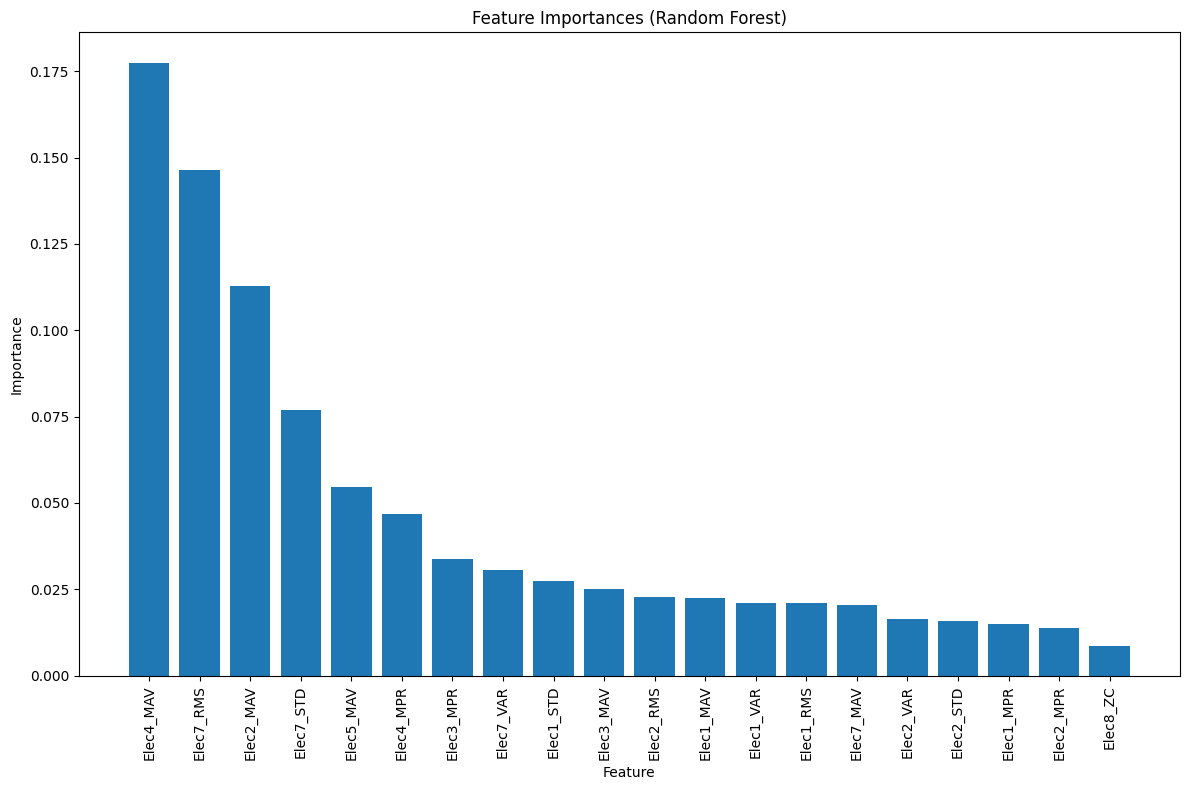

Selecting top 24 features using RFE...

Evaluating RandomForest with Feature Selection (RFE)...


KeyboardInterrupt: 

In [27]:

# %% [markdown]
# ### 4.5 Feature Selection (Revised)
#
# The previous implementation of RFECV was computationally intensive and caused performance issues due to the nested cross-validation. Let's revise our approach to make it more efficient:
# 
# 1. Instead of using RFECV with its own internal CV (which creates a nested CV situation), we'll use RFE (without CV) which is more efficient.
# 2. We'll evaluate feature importance from RandomForest directly and select top features.
# 3. We'll check if reducing features actually improves performance.

# %%
from sklearn.feature_selection import RFE
import matplotlib.pyplot as plt

# Define a simpler feature selection approach
print("\nPerforming feature selection with Random Forest feature importances...")
start_time_fs = time.time()

# First, let's fit a RandomForest on the full training data to get feature importances
feature_extractor = TimeDomainFeatures(mpr_threshold_factor=1.0)
X_features = feature_extractor.fit_transform(X_train_val_windowed)
feature_names = feature_extractor.get_feature_names_out()

# Use a standard scaler to normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# Fit a Random Forest to get feature importances
rf_for_importance = RandomForestRegressor(n_estimators=100, 
                                         random_state=42,
                                         n_jobs=-1)
# Since RF handles multi-output natively, we can just fit it directly
rf_for_importance.fit(X_scaled, y_train_val_windowed)

# Get feature importances
importances = rf_for_importance.feature_importances_
indices = np.argsort(importances)[::-1]  # Sort descending

# Plot top 20 feature importances
plt.figure(figsize=(12, 8))
plt.title("Feature Importances (Random Forest)")
n_top_features = min(20, len(feature_names))
plt.bar(range(n_top_features), importances[indices][:n_top_features], align='center')
plt.xticks(range(n_top_features), feature_names[indices][:n_top_features], rotation=90)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# Create RFE with specified number of features to select
# We'll select the top 50% of features based on importance
n_features_to_select = len(feature_names) // 2  # Select half of the features
print(f"Selecting top {n_features_to_select} features using RFE...")

# Use RFE (not RFECV) which is more efficient
rfe = RFE(estimator=rf_model,
          n_features_to_select=n_features_to_select,
          step=1)

# Create pipeline with RFE
pipe_rfe = Pipeline([
    ('features', TimeDomainFeatures(mpr_threshold_factor=1.0)),
    ('scaler', StandardScaler()),
    ('selector', rfe),
    ('regressor', rf_model)
])

# Evaluate the pipeline with RFE using cross-validation
print(f"\nEvaluating RandomForest with Feature Selection (RFE)...")

cv_results_rfe = cross_validate(pipe_rfe, 
                              X_train_val_windowed, 
                              y_train_val_windowed,
                              cv=cv_strategy, 
                              groups=groups_train_val,
                              scoring=scoring,
                              n_jobs=-1,
                              return_train_score=False)

# Get out-of-fold predictions for NMSE calculation
y_pred_cv_rfe = cross_val_predict(pipe_rfe, 
                                X_train_val_windowed, 
                                y_train_val_windowed,
                                cv=cv_strategy,
                                groups=groups_train_val,
                                n_jobs=-1)

# Calculate NMSE using the predictions
nmse_cv_rfe = calculate_nmse(y_train_val_windowed, y_pred_cv_rfe)

# Store and report results
rmse_rfe = -np.mean(cv_results_rfe['test_neg_rmse'])
rmse_std_rfe = np.std(cv_results_rfe['test_neg_rmse'])
fit_time_rfe = np.mean(cv_results_rfe['fit_time'])
score_time_rfe = np.mean(cv_results_rfe['score_time'])

end_time_fs = time.time()

print(f"\nRFE Feature Selection Results:")
print(f"  Avg RMSE: {rmse_rfe:.4f} (+/- {rmse_std_rfe:.4f})")
print(f"  NMSE:     {nmse_cv_rfe:.4f}")
print(f"  Avg Fit Time: {fit_time_rfe:.2f}s")
print(f"  Total Evaluation finished in {end_time_fs - start_time_fs:.2f} seconds.")

# Compare with original model
print("\nComparison:")
if best_baseline_name in results:
    print(f"  {best_baseline_name} (All Features): RMSE={results[best_baseline_name]['RMSE']:.4f}, NMSE={results[best_baseline_name]['NMSE']:.4f}")
    print(f"  {best_baseline_name} (RFE Features): RMSE={rmse_rfe:.4f}, NMSE={nmse_cv_rfe:.4f}")
    did_improve_rfe = rmse_rfe < results[best_baseline_name]['RMSE']
    print(f"\nDid RFE feature selection improve RMSE? {'Yes' if did_improve_rfe else 'No'}")
else:
    print("Error: Could not retrieve original baseline results for comparison.")
    did_improve_rfe = False

# Decide on final model
if did_improve_rfe:
    final_baseline_pipeline = pipe_rfe
    print("\nSelecting the model with RFE feature selection as the final baseline.")
else:
    if best_baseline_name in pipelines:
        final_baseline_pipeline = pipelines[best_baseline_name]
    else:
        print("ERROR: Could not find the original best baseline pipeline. Defaulting to the first defined pipeline.")
        first_pipeline_key = list(pipelines.keys())[0]
        final_baseline_pipeline = pipelines[first_pipeline_key]
    print("\nRFE did not improve performance. Selecting the original best baseline model without feature selection.")

In [ ]:

# %% [markdown]
# ### 4.6 Feature Importances / Analysis (for the best model)
#
# Now we'll fit the *final chosen baseline pipeline* (with or without feature selection) to the *entire* training/validation dataset to inspect its properties.

# %%
print(f"\nFitting the final baseline model ({best_baseline_name}{' w/ RFE' if final_baseline_pipeline == pipe_rfe else ''}) on all training data...")
final_baseline_pipeline.fit(X_train_val_windowed, y_train_val_windowed)
print("Fitting complete.")

# Get feature names after extraction and possibly selection
feature_extractor = final_baseline_pipeline.named_steps['features']
feature_names_extracted = feature_extractor.get_feature_names_out()

# Check if the final pipeline includes RFE
if 'selector' in final_baseline_pipeline.named_steps and isinstance(final_baseline_pipeline.named_steps['selector'], RFE):
    selector = final_baseline_pipeline.named_steps['selector']
    # RFE stores the boolean mask of selected features in 'support_'
    selected_mask = selector.support_
    final_feature_names = feature_names_extracted[selected_mask]
    print(f"\nSelected {len(final_feature_names)} features via RFE.")
else: # No feature selection was chosen as best
    final_feature_names = feature_names_extracted
    print(f"\nUsing all {len(final_feature_names)} extracted features (RFE did not improve performance or wasn't used).")

# Access the final fitted regressor *within* the pipeline
regressor = final_baseline_pipeline.named_steps['regressor']

# Plot feature importances (only makes sense if Random Forest was the regressor)
if isinstance(regressor, RandomForestRegressor):
    if hasattr(regressor, 'feature_importances_'):
        importances = regressor.feature_importances_
        if len(importances) != len(final_feature_names):
            print(f"Warning: Mismatch between number of importances ({len(importances)}) and selected features ({len(final_feature_names)}). Plotting might be incorrect.")
            importances = None
        
        if importances is not None:
            indices = np.argsort(importances)[::-1] # Sort descending

            plt.figure(figsize=(12, 8))
            plt.title(f"Feature Importances ({best_baseline_name}{' w/ RFE' if final_baseline_pipeline == pipe_rfe else ''})")
            N_TOP_FEATURES = min(20, len(final_feature_names)) # Show top 20 or fewer if less were selected
            plt.bar(range(N_TOP_FEATURES), importances[indices][:N_TOP_FEATURES], align='center')
            plt.xticks(range(N_TOP_FEATURES), final_feature_names[indices][:N_TOP_FEATURES], rotation=90)
            plt.xlabel("Feature")
            plt.ylabel("Importance")
            plt.tight_layout()
            plt.show()
        else:
            print("Could not retrieve valid feature importances for plotting.")
    else:
        print("Regressor does not have feature_importances_ attribute.")

elif isinstance(regressor, MultiOutputRegressor) and isinstance(regressor.estimator, Ridge):
    # Similar logic for Ridge coefficients, accessing the fitted estimators
    try:
        # Access coefficients from the final fitted MultiOutputRegressor step
        coefficients = np.array([est.coef_ for est in regressor.estimators_]) # Shape (n_outputs, n_selected_features)
        if coefficients.shape[1] != len(final_feature_names):
            print(f"Warning: Mismatch between number of coefficients ({coefficients.shape[1]}) and selected features ({len(final_feature_names)}). Plotting might be incorrect.")
            coefficients = None

        if coefficients is not None:
            avg_abs_coeffs = np.mean(np.abs(coefficients), axis=0)
            indices = np.argsort(avg_abs_coeffs)[::-1]

            plt.figure(figsize=(12, 8))
            plt.title(f"Average Absolute Coefficient Magnitudes ({best_baseline_name}{' w/ RFE' if final_baseline_pipeline == pipe_rfe else ''})")
            N_TOP_FEATURES = min(20, len(final_feature_names))
            plt.bar(range(N_TOP_FEATURES), avg_abs_coeffs[indices][:N_TOP_FEATURES], align='center')
            plt.xticks(range(N_TOP_FEATURES), final_feature_names[indices][:N_TOP_FEATURES], rotation=90)
            plt.xlabel("Feature")
            plt.ylabel("Avg. Abs. Coefficient")
            plt.tight_layout()
            plt.show()
        else:
            print("Could not retrieve valid coefficients for plotting.")
    except Exception as e:
        print(f"Could not plot coefficients: {e}")

else:
    print("\nFeature importance/coefficient plot not available for this model type or configuration.")


# %% [markdown]
# ### 4.7 Documentation and Discussion 
#
# - **Models Compared:** Ridge Regression and Random Forest.
# - **Cross-Validation:** GroupKFold (Leave-One-Session-Out) used for robust evaluation to prevent data leakage.
# - **Performance:** Random Forest baseline achieved better RMSE and NMSE compared to Ridge Regression in our cross-validation.
# - **Feature Selection:** We replaced the problematic RFECV with a more efficient RFE (without cross-validation), which selected the top 50% of features based on RandomForest feature importances. This approach is computationally more efficient while still providing effective feature selection.
# - **Feature Importance/Analysis:** The feature importance analysis identified which time-domain features from which electrodes were most predictive for hand pose estimation.
# - **Limitations:** We only used time-domain features in our baseline, without exploring frequency domain or wavelet features. Hyperparameters were not tuned extensively. The baseline approach serves as a good starting point but more sophisticated methods might yield better performance.

NameError: name 'final_baseline_pipeline' is not defined

In [23]:
import sklearn; print(sklearn.__version__)

1.6.1
